# 02 — Decision Engine

**Goal**: Keep analysis clear and business-credible while adding pragmatic guardrails.

### What this notebook does
- Loads the SaaS snapshot and aggregates KPIs at Region x Segment.
- Runs what-if scenarios with a simple policy model.
- Provides a **guarded greedy** plan under budget with realistic constraints:
  - per-cell uplift caps (avoid stacking unrealistic growth)
  - diminishing returns when repeating the same lever on the same cell
  - max steps per cell/lever
  - payback gate (reject moves with payback beyond a target months)
  - **minimum net impact guardrail** (reject moves with negligible business impact)
- Outputs a compact comparison table and an heatmap.

### How to Use
**Prerequisites**
```
ai-decision-intelligence-main/
├── data/processed/saas_financial_snapshot.csv
├── src/decision_engine/
│   ├── heatmap_region_segment.py                      (segment heatmap)
│   ├── kpis.py                                        (KPI computation)
│   └── policies.py                                    (pure, caps/decay handled there)
└── notebooks/02_decision_engine_v2_1_optimized.ipynb (this file)
```

**Execution**
1. Run cells top to bottom
2. Adjust guardrails (BUDGET, CAPS, DECAY, MIN_DELTA_NET, MAX_ITER) if needed
3. Results exported to `../outputs/decision_engine_outputs/`

**Deliverables**
- Baseline KPIs (GRR, NRR, Net ARR)
- Scenario comparisons (3 strategies)
- Greedy ROI-optimized plan under budget with guardrails
- Heatmap (Region x Segment) and exported CSV/JSON


## 01 — Imports & config

Set up Python environment, import KPI and policy modules, and configure plot style and format helpers.

In [124]:
import sys
import json
from pathlib import Path
from collections import defaultdict
import importlib

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Project root & src path (works if notebook lives in notebooks/)
notebook_dir = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
src_path = project_root / 'src' / 'functions'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Local modules
try:
    from kpis import compute_cfo_kpis
    import policies
    importlib.reload(policies)
    from policies import apply_policy
    from heatmap_region_segment import plot_region_segment_heatmap
except Exception as e:
    raise ImportError(
        f'❌ Failed to import local modules: {e}\n'
        f'Ensure src/functions/ contains kpis.py and policies.py'
    )

# Plot configs
mpl.rcParams['font.family'] = 'DejaVu Sans'  # avoid glyph warnings
sns.set_theme(style='whitegrid')
plt.rcParams.update({'axes.titlesize':12,'axes.labelsize':10,'legend.fontsize':9,'figure.figsize':(9,4.8)})

# Format helpers
fmt_usd = lambda x: f"{x:,.0f} $".replace(',', ' ')
fmt_pct = lambda x: f"{x*100:,.1f}%".replace(',', ' ')


## 02 — Load & aggregate (region × segment)

Load the SaaS financial snapshot and build region-segment KPI cells for scenario modeling.

In [125]:
data_path = project_root / 'data' / 'processed' / 'saas_financial_snapshot.csv'
if not data_path.exists():
    raise FileNotFoundError(
        f'❌ Data file not found: {data_path}\n'
        f'Expected: project_root/data/processed/saas_financial_snapshot.csv'
    )

df = pd.read_csv(data_path)

# Required schema
required_cols = [
    'annual_contract_value','opening_arr','new_arr','churned_arr',
    'reactivated_arr','expansion_arr','contraction_arr','net_arr_change'
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'❌ Missing required columns in CSV: {missing_cols}')

for col in required_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

df['segment'] = df['segment'].fillna('SMB')
df['region']  = df['region'].fillna('Other')

kpi_by_region_segment = df.groupby(['region','segment']).agg(
    opening=('opening_arr','sum'),
    arr=('annual_contract_value','sum'),
    churned=('churned_arr','sum'),
    new=('new_arr','sum'),
    reactivated=('reactivated_arr','sum'),
    expansion=('expansion_arr','sum'),
    contraction=('contraction_arr','sum'),
    accounts=('account_id','nunique')
).reset_index()

print(f'✓ Loaded {len(df):,} rows → aggregated to {len(kpi_by_region_segment)} cells')
kpi_by_region_segment.head()


✓ Loaded 500 rows → aggregated to 9 cells


,region,segment,opening,arr,churned,new,reactivated,expansion,contraction,accounts
0,APAC,Corporate,391344.0,1043748,51744.0,426456.0,209028.0,5613.08,3444.25,28
1,APAC,Enterprise,203328.0,841788,95772.0,549204.0,178452.0,21663.72,1921.48,21
2,APAC,SMB,311556.0,924684,11940.0,602664.0,119004.0,743.53,1952.45,32
3,EMEA,Corporate,286956.0,993468,39060.0,477252.0,166500.0,22588.16,11451.09,31
4,EMEA,Enterprise,231108.0,1506108,125148.0,502704.0,253476.0,25257.10,249.42,39


## 03 — Baseline CFO KPIs (opening-based)

Calculate global GRR, NRR, and net ARR at the company level—this is the reference point for all scenarios.

In [126]:
# Baseline at global level (numeric for calculations)
base_global = compute_cfo_kpis(kpi_by_region_segment.sum(numeric_only=True).to_frame().T, format_output=False)
base_global


,opening,arr,churned,new,reactivated,expansion,contraction,accounts,net,gross_churn,GRR,NRR,net_growth_pct
0,4891680.0,14834016.0,1439928.0,9281448.0,3777048.0,227782.76,96987.72,500.0,11749363.04,0.294363,0.705637,0.732376,2.401908


## 04 — Guardrails & effort model (to update)

Define caps, decay factors, payback gates, and minimum impact thresholds. Tune these to match your business constraints.

In [127]:
# Effort coefficients (abstract units)
DEFAULT_EFFORT = {
    'a_churn': 1.0,
    'a_new':   0.6,
    'a_react': 0.4,
    'a_exp':   0.7,
    'a_cont':  0.8,
}

# Caps & decay
MAX_NEW_UPLIFT   = 0.20    # +20% cap per cell
MAX_REACT_UPLIFT = 0.30    # +30% cap per cell
CAPS  = {'max_new_uplift': MAX_NEW_UPLIFT, 'max_react_uplift': MAX_REACT_UPLIFT}
DECAY = 0.85               # diminishing returns factor per repeated move
MAX_STEPS_PER_CELL_LEVER = 5

# Effort -> $ mapping for payback gate
EFFORT_UNIT_TO_USD = 10_000.0  # 1 unit = $10k all-in cost (Sales+Mktg+CS blended)
GROSS_MARGIN    = 0.80
MAX_PAYBACK_MONTHS = 18

# NEW: minimum business-impact guardrail
MIN_DELTA_NET   = 1_000.0   # reject moves with <1k $ net ARR impact

# Elementary steps per lever (kept realistic)
STEPS = {
    'churn_bps': 50,     # reduce churn by 50 bps per step
    'new_pct':   0.02,   # +2% new logo ARR per step
    'react_pct': 0.05,   # +5% reactivation ARR per step
}

# Safety: max greedy iterations
MAX_ITER = 500


## 05 — Scenario runner (pure what-if, baseline passed once)

Run multiple named strategies (retention-first, growth-balanced, etc.) and compare their KPI impact.

In [128]:
def run_scenario(kpi_df: pd.DataFrame, policy: dict, name: str,
                 baseline_g: pd.DataFrame,
                 effort_coeffs=None, caps=None):
    """Apply a single policy, return simulated KPIs vs provided baseline."""
    if effort_coeffs is None:
        effort_coeffs = DEFAULT_EFFORT
    if caps is None:
        caps = CAPS

    kpi_sim, effort_units = apply_policy(kpi_df, policy, effort_coeffs=effort_coeffs, caps=caps)
    sim_g  = compute_cfo_kpis(kpi_sim.sum(numeric_only=True).to_frame().T, format_output=False)
    delta_g = pd.DataFrame({
        'Scenario':      [name],
        'Delta Net ARR ($)': sim_g['net'].iat[0] - baseline_g['net'].iat[0],
        'Delta Net Growth (%)': (sim_g['net_growth_pct'].iat[0] - baseline_g['net_growth_pct'].iat[0]) * 100,
        'Effort (units)':   effort_units,
    })
    return kpi_sim, delta_g

def compare_scenarios(kpi_df: pd.DataFrame, scenarios: dict,
                      baseline_g: pd.DataFrame,
                      effort_coeffs=None, caps=None) -> pd.DataFrame:
    """Run multiple scenarios — baseline passed once to avoid re-compute noise."""
    rows = []
    for name, pol in scenarios.items():
        _, d = run_scenario(kpi_df, pol, name, baseline_g,
                            effort_coeffs=effort_coeffs, caps=caps)
        rows.append(d.iloc[0])
    out = pd.DataFrame(rows)
    return out[['Scenario','Delta Net ARR ($)','Delta Net Growth (%)','Effort (units)']]


## 06 — Greedy engine (no globals; payback + min impact; iteration safety)

ROI-driven optimizer: picks best moves sequentially under budget, with built-in payback validation and diminishing returns.

1. Payback Gate

In [129]:
def payback_ok(delta_net_usd: float, effort_units: float) -> bool:
    """Payback(months) = Cost / (Gross Profit / 12) ≤ MAX_PAYBACK_MONTHS, and Delta Net >= MIN_DELTA_NET."""
    if delta_net_usd < MIN_DELTA_NET:
        return False
    gp = max(0.0, delta_net_usd * GROSS_MARGIN)
    cost = effort_units * EFFORT_UNIT_TO_USD
    if gp <= 0:
        return False
    payback_mo = cost / (gp / 12.0)
    return payback_mo <= MAX_PAYBACK_MONTHS

2. ROI Maximizer (Best Move Finder)

In [130]:
def best_move_given_state(kpi_sim: pd.DataFrame,
                          applied_counts: dict,
                          effort_coeffs=None, caps=None, steps: dict = None):
    """Evaluate all candidate moves; return best ROI dict or None."""
    if effort_coeffs is None:
        effort_coeffs = DEFAULT_EFFORT
    if caps is None:
        caps = CAPS
    if steps is None:
        steps = STEPS

    base_g = compute_cfo_kpis(kpi_sim.sum(numeric_only=True).to_frame().T, format_output=False)
    base_net = base_g['net'].iat[0]

    candidates = []
    for _, row in kpi_sim.iterrows():
        reg, seg = row['region'], row['segment']
        for lever, step in steps.items():
            n_used = applied_counts.get((reg, seg, lever), 0)
            if n_used >= MAX_STEPS_PER_CELL_LEVER:
                continue
            effective_step = step * (DECAY ** n_used)
            if effective_step <= 0:
                continue

            pol = {'cell': {(reg, seg): {lever: effective_step}}}
            after, effort = apply_policy(kpi_sim, pol, effort_coeffs=effort_coeffs, caps=caps)
            after_g = compute_cfo_kpis(after.sum(numeric_only=True).to_frame().T, format_output=False)
            dnet = after_g['net'].iat[0] - base_net

            if not payback_ok(dnet, effort):
                continue
            roi = dnet / max(effort, 1e-6)
            candidates.append({
                'region': reg,
                'segment': seg,
                'lever': lever,
                'step': effective_step,
                'delta_net': dnet,
                'effort': effort,
                'ROI': roi,
            })

    if not candidates:
        return None
    cand_df = pd.DataFrame(candidates).sort_values('ROI', ascending=False)
    return cand_df.iloc[0].to_dict()


3. Greedy Allocator (Budget-Constrained Loop)

In [131]:

def greedy_allocate(kpi_df: pd.DataFrame, budget: float,
                    effort_coeffs=None, caps=None, steps: dict = None,
                    max_iter: int = MAX_ITER):
    """Budget-constrained greedy with caps, decay, max steps, payback, min impact, and iteration limit."""
    if effort_coeffs is None:
        effort_coeffs = DEFAULT_EFFORT
    if caps is None:
        caps = CAPS
    if steps is None:
        steps = STEPS

    applied_counts = defaultdict(int)  # local, no global state
    kpi_sim = kpi_df.copy()
    spent = 0.0
    picks = []

    it = 0
    while spent < budget and it < max_iter:
        it += 1
        move = best_move_given_state(kpi_sim, applied_counts, effort_coeffs, caps=caps, steps=steps)
        if move is None:
            break
        if spent + move['effort'] > budget:
            break

        pol = {'cell': {(move['region'], move['segment']): {move['lever']: move['step']}}}
        after, _ = apply_policy(kpi_sim, pol, effort_coeffs=effort_coeffs, caps=caps)
        kpi_sim = after
        spent += move['effort']
        picks.append(move)

        applied_counts[(move['region'], move['segment'], move['lever'])] += 1

    base_g  = compute_cfo_kpis(kpi_df.sum(numeric_only=True).to_frame().T, format_output=False)
    final_g = compute_cfo_kpis(kpi_sim.sum(numeric_only=True).to_frame().T, format_output=False)
    summary = pd.DataFrame([{
        'Budget used (units)': spent,
        'Delta Net ARR ($)':    final_g['net'].iat[0] - base_g['net'].iat[0],
        'Delta Net Growth (%)': (final_g['net_growth_pct'].iat[0] - base_g['net_growth_pct'].iat[0]) * 100,
    }])
    return kpi_sim, pd.DataFrame(picks), summary


## 07 — Scenarios (examples) & Comparison

Define three business strategies and compare their simulated outcomes (GRR, NRR, net ARR, effort).

In [132]:
# Strategy 1: Retention-first (reduce churn in high-value segments)
policy_retention = {
    'segment': {'Enterprise': {'churn_bps': 150}},
    'cell':    {('EMEA','Mid-Market'): {'churn_bps': 150}},
}

# Strategy 2: Balanced Growth (new + reactivation)
policy_growth_balanced = {
    'region':  {'EMEA': {'new_pct': 0.06}},
    'segment': {'SMB': {'new_pct': 0.04, 'react_pct': 0.10}},
}

# Strategy 3: Protect Whales (surgical on key accounts)
policy_protect_whales = {
    'cell': {('APAC','Enterprise'): {'churn_bps': 100, 'react_pct': 0.05}},
}

scenarios = {
    'Retention-first': policy_retention,
    'Balanced Growth': policy_growth_balanced,
    'Protect Whales':  policy_protect_whales,
}

comp_df = compare_scenarios(kpi_by_region_segment, scenarios, baseline_g=base_global)
comp_df


,Scenario,Delta Net ARR ($),Delta Net Growth (%),Effort (units)
0,Retention-first,372144.000,7.607693,1.170435
0,Balanced Growth,345634.944,7.065772,0.518289
0,Protect Whales,104694.600,2.140259,0.488575


## 08 — Greedy under Budget

Run the greedy allocator with a fixed budget constraint. Output the best moves ranked by ROI.

In [133]:
BUDGET = 50.0
kpi_sim_after, picks_df, summary_df = greedy_allocate(kpi_by_region_segment, budget=BUDGET)
summary_df


,Budget used (units),Delta Net ARR ($),Delta Net Growth (%)
0,4.036812,2.902352e+06,59.332408


## 09 — Visualization: Delta Net created by move

Heatmap showing where net ARR gains were generated (normalized by region ARR to avoid size bias).

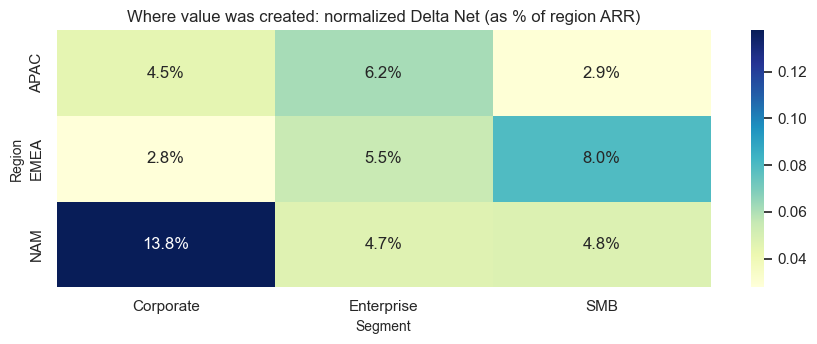

In [134]:
def build_delta_by_segment(base_kpi_df: pd.DataFrame, final_kpi_df: pd.DataFrame) -> pd.DataFrame:
    b = base_kpi_df[['region','segment','arr','net']].rename(columns={'net':'net_base'})
    f = final_kpi_df[['region','segment','net']].rename(columns={'net':'net_sim'})
    m = b.merge(f, on=['region','segment'], how='left')
    reg_arr = b.groupby('region', as_index=False)['arr'].sum().rename(columns={'arr':'arr_region'})
    m = m.merge(reg_arr, on='region', how='left')
    m['delta_net'] = m['net_sim'].fillna(0) - m['net_base'].fillna(0)
    m['delta_net_pct_region'] = np.where(m['arr_region']>0, m['delta_net']/m['arr_region'], 0.0)
    return m

# Build base/final segment-level KPIs for plotting
base_eval  = kpi_by_region_segment.copy()
base_eval['net'] = kpi_by_region_segment['new'] + kpi_by_region_segment['reactivated'] + kpi_by_region_segment['expansion'] - kpi_by_region_segment['contraction'] - kpi_by_region_segment['churned']
final_eval = kpi_sim_after.copy()
final_eval['net'] = kpi_sim_after['new'] + kpi_sim_after['reactivated'] + kpi_sim_after['expansion'] - kpi_sim_after['contraction'] - kpi_sim_after['churned']

delta_kpi_by_segment = build_delta_by_segment(base_eval, final_eval)
plot_region_segment_heatmap(
    delta_kpi_by_segment,
    'Where value was created: normalized Delta Net (as % of region ARR)'
)


## 10 — Executive Summary

Print baseline, scenarios, and top greedy moves for board-ready presentation. 
Highlights ROI and payback metrics.

In [135]:
print('='*60)
print('BASELINE (global)')
print('-'*60)
print(base_global[['opening','GRR','NRR','net']].to_string(index=False))

print('' + '='*60)
print('SCENARIO COMPARISON')
print('-'*60)
print(comp_df.to_string(index=False))

print('' + '='*60)
print('GREEDY OPTIMIZATION RESULTS')
print('-'*60)
print(summary_df.to_string(index=False))

if not picks_df.empty:
    top3 = picks_df.sort_values('ROI', ascending=False).head(3).copy()
    top3['Delta Net (k$)'] = (top3['delta_net'] / 1000).round(1)
    top3['Effort (units)'] = top3['effort'].round(2)
    top3['ROI ($ per unit)'] = top3['ROI'].round(0).astype(int)
    display_cols = ['region','segment','lever','Delta Net (k$)','Effort (units)','ROI ($ per unit)']

    print('' + '='*60)
    print('TOP 3 GREEDY MOVES (sorted by ROI)')
    print('-'*60)
    with pd.option_context('display.max_rows', None, 'display.width', None):
        print(top3[display_cols].to_string(index=False))


BASELINE (global)
------------------------------------------------------------
  opening      GRR      NRR         net
4891680.0 0.705637 0.732376 11749363.04
SCENARIO COMPARISON
------------------------------------------------------------
       Scenario  Delta Net ARR ($)  Delta Net Growth (%)  Effort (units)
Retention-first         372144.000              7.607693        1.170435
Balanced Growth         345634.944              7.065772        0.518289
 Protect Whales         104694.600              2.140259        0.488575
GREEDY OPTIMIZATION RESULTS
------------------------------------------------------------
 Budget used (units)  Delta Net ARR ($)  Delta Net Growth (%)
            4.036812       2.902352e+06             59.332408
TOP 3 GREEDY MOVES (sorted by ROI)
------------------------------------------------------------
region   segment     lever  Delta Net (k$)  Effort (units)  ROI ($ per unit)
   NAM Corporate react_pct            38.8            0.01           3572190
   NA

## 11 — Export (CSV/JSON) for deck & automation

Save scenario comparisons and greedy results to outputs/ for PowerPoint pipelines and downstream tools.

In [136]:
export_dir = project_root / 'outputs' / 'decision_engine_outputs'
export_dir.mkdir(parents=True, exist_ok=True)
scenario_out = export_dir / 'scenario_compare.csv'
greedy_out   = export_dir / 'greedy_summary.json'

scenario_export = comp_df.rename(columns={
    'Scenario':      'option',
    'Delta Net ARR ($)': 'delta_net_usd',
    'Delta Net Growth (%)': 'delta_net_growth_pct',
    'Effort (units)':   'effort_units',
})[['option','delta_net_usd','delta_net_growth_pct','effort_units']]
scenario_export.to_csv(scenario_out, index=False)

greedy_payload = {
    'budget_used_units': float(summary_df['Budget used (units)'].iat[0]) if not summary_df.empty else 0.0,
    'delta_net_usd':  float(summary_df['Delta Net ARR ($)'].iat[0]) if not summary_df.empty else 0.0,
    'delta_net_growth_pct': float(summary_df['Delta Net Growth (%)'].iat[0]) if not summary_df.empty else 0.0,
}
with greedy_out.open('w', encoding='utf-8') as f:
    json.dump(greedy_payload, f, indent=2)

print(f'✓ Exported to {export_dir.relative_to(project_root)}/')
print(f'  - {scenario_out.name}')
print(f'  - {greedy_out.name}')


✓ Exported to outputs\decision_engine_outputs/
  - scenario_compare.csv
  - greedy_summary.json
